In [1]:
import sys
import os

sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2
import globals
import parse_data.prepare_data as prepare_data
import data_extraction.trial_list_filters as trial_list_filters
from matplotlib.patches import Wedge
from matplotlib import pyplot as plt
import data_extraction.get_indices as get_indices
import parse_data.identify_filepaths as identify_filepaths
import globals
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.patches import Polygon
from matplotlib import cm
import math
from parse_data import flip_rotate_trajectories
# import occupancy_and_strategy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import data_strings
import data_extraction.data_saving as data_saving
import plotting.plot_octagon as plot_octagon
import analysis.heatmap_phigh as heatmap_phigh
import pickle
import os

In [3]:
data_folder = '/Volumes/ogma/human_octagon/RAW/standard'
#personal_data_csv = '/Users/benny/Desktop/MSc/Project/Git/repos/main_copy/questionnaire_analysis/questionnaire_data/personal_data.csv'

In [4]:
json_filenames_social, json_filenames_solo = identify_filepaths.get_filenames(data_folder)

In [5]:
_, trial_lists_social = prepare_data.prepare_data(data_folder, json_filenames_social, combine=False)

IntProgress(value=0, max=101)

filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-31-00_YW13_JL13_Social.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240927_1/2024-09-27_14-25-20_SH27_EN27_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241017_1/2024-10-17_14-28-40_SP17_AW17_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241017_2/2024-10-17_16-41-38_ZH17_EM17_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241112_1/2024-11-12_13-31-14_KA12_WM12_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/241112_2/2024-11-12_15-23-24_FA12_SL12_Social.json
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/h

In [6]:
_, trial_lists_solo = prepare_data.prepare_data(data_folder, json_filenames_solo, combine=False)

IntProgress(value=0, max=404)

filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-23-37_YW13_FirstSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-53-34_YW13_SecondSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-23-50_JL13_FirstSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocessing complete.
filepath: /Volumes/ogma/human_octagon/RAW/standard/240913_1/2024-09-13_11-53-56_JL13_SecondSolo.json
Data is from period before 2024-09-13 00:00:00
Running dataframe through playerinfo_playerposition_conversion.
Loading complete.
Preprocess

In [10]:
# get every other trial list from solo to isolate first and second solos
second_solo_lists = []
for i in range(1, len(json_filenames_solo), 2):
    second_solo = json_filenames_solo[i]
    second_solo_list = trial_lists_solo[i]
    second_solo_lists.append(second_solo_list)
    print(second_solo)

240913_1/2024-09-13_11-53-34_YW13_SecondSolo.json
240913_1/2024-09-13_11-53-56_JL13_SecondSolo.json
240927_1/2024-09-27_14-45-55_SH27_SecondSolo.json
240927_1/2024-09-27_14-45-46_EN27_SecondSolo.json
241017_1/2024-10-17_14-50-03_SP17_SecondSolo.json
241017_1/2024-10-17_14-51-22_AW17_SecondSolo.json
241017_2/2024-10-17_17-11-46_ZH17_SecondSolo.json
241017_2/2024-10-17_17-12-29_EM17_SecondSolo.json
241112_1/2024-11-12_13-50-23_KA12_SecondSolo.json
241112_1/2024-11-12_13-50-20_WM12_SecondSolo.json
241112_2/2024-11-12_15-44-54_FA12_SecondSolo.json
241112_2/2024-11-12_15-45-35_SL12_SecondSolo.json
241113_1/2024-11-13_14-37-06_NK13_SecondSolo.json
241113_1/2024-11-13_14-37-20_RD13_SecondSolo.json
241113_2/2024-11-13_15-51-39_YL13_SecondSolo.json
241113_2/2024-11-13_15-51-16_HC13_SecondSolo.json
241119_1/2024-11-19_14-44-00_AV19_SecondSolo.json
241119_1/2024-11-19_14-44-31_XG19_SecondSolo.json
241119_2/2024-11-19_15-47-53_SB19_SecondSolo.json
241119_2/2024-11-19_15-47-29_HH19_SecondSolo.json


Reworking loser's choice code to change of mind

In [87]:
trial_list = trial_lists_social[0]
trial_index = 0
trial = trial_list[trial_index]
loser_id = 0

In [11]:
from trajectory_analysis import trajectory_vectors
from analysis import loser_inferred_choice
from trajectory_analysis import trajectory_direction

In [12]:
def get_forgiving_blocks(mask, max_gap_frames=5):
    """Groups True values into blocks, allowing short False gaps."""
    blocks = []
    in_block = False
    start = 0
    gap_count = 0

    for i, val in enumerate(mask):
        if val:
            if not in_block:
                start = i
                in_block = True
            gap_count = 0
        else:
            if in_block:
                gap_count += 1
                if gap_count > max_gap_frames:
                    blocks.append((start, i - gap_count))
                    in_block = False

    if in_block:
        blocks.append((start, len(mask) - 1))

    return blocks


def detect_loser_change_of_mind_trial(
    trial,
    loser_id,
    final_choice_wall_num,
    trial_walls,
    window_size=5,
    align_min=0.85,
    align_diff_thresh=0.10,
    violation_max_frames=5,
    min_block_len=10,
):
    """
    Detects whether the loser first aligned with the alternative wall
    and then switched to the final inferred/actual chosen wall.

    Parameters
    ----------
    final_choice_wall_num : int
        Wall number treated as the player's final choice, e.g. inferred loser choice.
        Wall numbers are assumed to be 1-indexed.

    trial_walls : array-like
        The two relevant wall numbers for this trial, also 1-indexed.

    Returns
    -------
    dict with:
        change_of_mind : bool
        initial_wall : int or np.nan
        final_wall : int
        change_point : int or np.nan
        alignment_var : list
        blocks_final : list
        blocks_alt : list
        blocks_ambiguous : list
        cosine_similarity_trajectory : np.ndarray
    """

    trajectory = trajectory_vectors.extract_trial_player_trajectory(
        trial=trial,
        player_id=loser_id
    )

    cosine_similarity_trajectory = trajectory_direction.cosine_similarity_throughout_trajectory(
        trajectory,
        window_size=window_size,
        num_walls=8,
        calculate_thetas=False
    )

    n_frames = cosine_similarity_trajectory.shape[1]

    final_wall_idx = int(final_choice_wall_num) - 1

    trial_walls = np.asarray(trial_walls, dtype=int)
    alternative_walls = [w for w in trial_walls if w != final_choice_wall_num]

    if len(alternative_walls) != 1:
        return {
            "change_of_mind": False,
            "initial_wall": np.nan,
            "final_wall": final_choice_wall_num,
            "change_point": np.nan,
            "alignment_var": np.zeros(n_frames).tolist(),
            "blocks_final": [],
            "blocks_alt": [],
            "blocks_ambiguous": [],
            "cosine_similarity_trajectory": cosine_similarity_trajectory,
        }

    #alt_wall_num = int(alternative_walls[0])
    #alt_wall_idx = alt_wall_num - 1

    trial_walls = get_indices.get_walls(trial)
    high_wall = int(trial_walls[0])
    low_wall = int(trial_walls[1])

    high_idx = high_wall - 1
    low_idx = low_wall - 1

    align_high = cosine_similarity_trajectory[high_idx, :]
    align_low = cosine_similarity_trajectory[low_idx, :]

    is_high = (
        (align_high > align_min) &
        ((align_high - align_low) >= align_diff_thresh)
    )

    is_low = (
        (align_low > align_min) &
        ((align_low - align_high) >= align_diff_thresh)
    )

    is_ambiguous = (
        (align_high > align_min) &
        (align_low > align_min) &
        (np.abs(align_high - align_low) < align_diff_thresh)
    )

    alignment_var = np.zeros(n_frames)
    alignment_var[is_high] = 1.0
    alignment_var[is_low] = -1.0
    alignment_var[is_ambiguous] = 0.5

    blocks_high = get_forgiving_blocks(is_high, violation_max_frames)
    blocks_low = get_forgiving_blocks(is_low, violation_max_frames)
    blocks_ambiguous = get_forgiving_blocks(is_ambiguous, violation_max_frames)

    blocks_high = [(s, e) for s, e in blocks_high if e - s + 1 >= min_block_len]
    blocks_low = [(s, e) for s, e in blocks_low if e - s + 1 >= min_block_len]

    return {
        "alignment_var": alignment_var.tolist(),
        "blocks_high": blocks_high,
        "blocks_low": blocks_low,
        "blocks_ambiguous": blocks_ambiguous,
        "high_wall": high_wall,
        "low_wall": low_wall,
        "cosine_similarity_trajectory": cosine_similarity_trajectory,
    }

In [13]:
def count_alignment_switches(alignment_var, min_block_len=5):
    """
    Counts switches between alternative (-1) and final (+1) alignment blocks.
    Ignores 0 and 0.5 states.
    """
    alignment_var = np.asarray(alignment_var)

    meaningful = np.where(
        (alignment_var == 1.0) | (alignment_var == -1.0),
        alignment_var,
        np.nan
    )

    blocks = []
    current_state = None
    start = None

    for i, state in enumerate(meaningful):
        if np.isnan(state):
            continue

        if current_state is None:
            current_state = state
            start = i

        elif state != current_state:
            end = i - 1
            if end - start + 1 >= min_block_len:
                blocks.append((current_state, start, end))

            current_state = state
            start = i

    if current_state is not None:
        end = len(meaningful) - 1
        if end - start + 1 >= min_block_len:
            blocks.append((current_state, start, end))

    switches = []
    for prev, curr in zip(blocks[:-1], blocks[1:]):
        prev_state, prev_start, prev_end = prev
        curr_state, curr_start, curr_end = curr

        if prev_state == 1 and curr_state == -1:
            switch_type = "High→Low"

        elif prev_state == -1 and curr_state == 1:
            switch_type = "Low→High"

        if prev_state != curr_state:
            switches.append({
                "from": "final" if prev_state == 1.0 else "alternative",
                "to": "final" if curr_state == 1.0 else "alternative",
                "switch_frame": curr_start,
                "previous_block": prev,
                "new_block": curr,
                "switch_type": switch_type
            })

    return {
        "n_switches": len(switches),
        "switches": switches,
        "blocks": blocks,
        "multiple_changes_of_mind": len(switches) > 1,
    }

In [14]:
def visualize_loser_change_of_mind(
    trial,
    loser_id,
    result,
    trial_walls=None
):
    """
    Visualise loser trajectory and alignment state.

    alignment_var coding:
        1.0  = aligned with high wall
       -1.0  = aligned with low wall
        0.5  = ambiguous high/low alignment
        0.0  = no clear alignment
    """

    trajectory = trajectory_vectors.extract_trial_player_trajectory(
        trial=trial,
        player_id=loser_id
    )

    x = trajectory[0, :]
    y = trajectory[1, :]

    if trial_walls is None:
        trial_walls = get_indices.get_walls(trial)

    high_wall = int(trial_walls[0])
    low_wall = int(trial_walls[1])

    high_idx = high_wall - 1
    low_idx = low_wall - 1

    cosine_similarity_trajectory = result["cosine_similarity_trajectory"]
    alignment_var = np.asarray(result["alignment_var"])

    align_high = cosine_similarity_trajectory[high_idx, :]
    align_low = cosine_similarity_trajectory[low_idx, :]

    n_frames = min(len(alignment_var), len(x), len(y))
    x = x[:n_frames]
    y = y[:n_frames]
    alignment_var = alignment_var[:n_frames]
    align_high = align_high[:n_frames]
    align_low = align_low[:n_frames]

    fig, axs = plt.subplots(
        2, 1,
        figsize=(9, 10),
        gridspec_kw={"height_ratios": [2.5, 2.5]}
    )

    # -------------------------
    # 1. Trajectory
    # -------------------------

    colors = []
    for state in alignment_var:
        if state == 1.0:
            colors.append("blue")       # high wall
        elif state == -1.0:
            colors.append("red")        # low wall
        elif state == 0.5:
            colors.append("gold")       # ambiguous
        else:
            colors.append("lightgrey")  # no clear alignment

    # Plot one or multiple change points
    change_points = result.get("change_points", None)

    if change_points is None:
        change_point = result.get("change_point", np.nan)
        change_points = [] if np.isnan(change_point) else [change_point]

    # -------------------------
    # 2. Cosine similarity traces
    # -------------------------
    axs[0].plot(
        align_high,
        color="blue",
        label=f"High wall {high_wall}",
    )
    axs[0].plot(
        align_low,
        color="red",
        label=f"Low wall {low_wall}",
    )

    for cp in change_points:
        if not np.isnan(cp):
            axs[0].axvline(int(cp), color="black", lw=2)

    axs[0].set_ylabel("Cosine similarity", fontsize=20)
    axs[0].legend(frameon=False, fontsize=20)

    # -------------------------
    # 3. State timeline
    # -------------------------
    axs[1].set_ylim(-1.5, 1.5)
    axs[1].plot(alignment_var, color="black", lw=3)

    axs[1].axhline(1, color="blue", alpha=0.5)
    axs[1].axhline(-1, color="red", alpha=0.5)
    axs[1].axhline(0.5, color="gold", alpha=0.5)

    for cp in change_points:
        if not np.isnan(cp):
            axs[1].axvline(int(cp), color="black", lw=2)

    axs[1].set_yticks([-1, 0, 0.5, 1])
    axs[1].set_yticklabels([
        "Low",
        "None",
        "Ambiguous",
        "High"
    ])
    axs[1].set_xlabel("Timepoint", fontsize=20)

    for ax in axs:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(axis='both', labelsize=20, width=1.5, length=6)
        
    plt.tight_layout()
    plt.show()

In [15]:
from matplotlib.lines import Line2D

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_change_of_mind_example_in_octagon(
    trajectory,
    alignment_var,
    change_points=None,
    headangle_vectors=None,
    start_label=True,
    final_label=True,
    show_start_headangle=True,
    head_arrow_len=5.0,
    ax=None
):
    """
    trajectory: 2 x timepoints array

    alignment_var:
        1.0  = high wall alignment / final alignment
       -1.0  = low wall alignment / alternative alignment
        0.5  = ambiguous
        0.0  = no clear alignment

    change_points:
        list of frame indices where switches occur

    headangles:
        2 x timepoints array of head-angle direction vectors.
        If provided, the function plots the first valid head direction
        at the start of the trajectory.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Your existing octagon plot
    plot_octagon.plot_octagon(ax=ax)

    x = trajectory[0, :]
    y = trajectory[1, :]
    n = min(len(x), len(alignment_var))

    x = x[:n]
    y = y[:n]
    alignment_var = np.asarray(alignment_var[:n])

    # Build trajectory line segments
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    colors = []
    for state in alignment_var[:-1]:
        if state == 1.0:
            colors.append("blue")
        elif state == -1.0:
            colors.append("red")
        elif state == 0.5:
            colors.append("gold")
        else:
            colors.append("lightgrey")

    lc = LineCollection(
        segments,
        colors=colors,
        linewidths=5,
        alpha=0.9,
        capstyle="round"
    )
    ax.add_collection(lc)

    # Start point
    if start_label:
        ax.scatter(
            x[0], y[0],
            c="lightgrey",
            s=80,
            edgecolors="black",
            zorder=10,
            label="Start"
        )

    # Starting head-angle / looking direction
    if show_start_headangle and headangle_vectors is not None:
        headangle_vectors = headangle_vectors[:, :n]

        valid_head = np.where(
            ~np.isnan(headangle_vectors[0, :]) &
            ~np.isnan(headangle_vectors[1, :]) &
            ~np.isnan(x) &
            ~np.isnan(y)
        )[0]

        if len(valid_head) > 0:
            h_idx = valid_head[0]

            head_dx = headangle_vectors[0, h_idx]
            head_dy = headangle_vectors[1, h_idx]

            norm = np.sqrt(head_dx**2 + head_dy**2)

            if norm > 0:
                head_dx = head_dx / norm
                head_dy = head_dy / norm

                ax.arrow(
                    x[h_idx],
                    y[h_idx],
                    head_dx * head_arrow_len,
                    head_dy * head_arrow_len,
                    width=0.25,
                    head_width=1,
                    head_length=1,
                    color="black",
                    length_includes_head=True,
                    zorder=15,
                    label="Start head direction"
                )

    # Final point
    if final_label:
        ax.scatter(
            x[-1], y[-1],
            c="tab:blue",
            s=120,
            edgecolors="black",
            zorder=10,
            label="Final position"
        )

    # Change-of-mind points
    if change_points is not None:
        for i, cp in enumerate(change_points):
            if 0 <= cp < n:
                ax.scatter(
                    x[cp], y[cp],
                    c="black",
                    s=100,
                    marker="X",
                    zorder=12,
                    label="Change point" if i == 0 else None
                )

    ax.set_aspect("equal")
    ax.axis("off")
    legend_elements = [

        Line2D(
            [0], [0],
            color='blue',
            lw=4,
            label='High wall alignment'
        ),

        Line2D(
            [0], [0],
            color='red',
            lw=4,
            label='Low wall alignment'
        ),

        Line2D(
            [0], [0],
            color='gold',
            lw=4,
            label='Ambiguous'
        ),

        Line2D(
            [0], [0],
            color='lightgrey',
            lw=4,
            label='No clear alignment'
        ),

        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor='lightgrey',
            markeredgecolor='black',
            markersize=8,
            label='Start'
        ),

        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor='tab:blue',
            markeredgecolor='black',
            markersize=10,
            label='Final position'
        ),

        Line2D(
            [0], [0],
            marker='X',
            linestyle='None',
            color='black',
            markersize=10,
            label='Change point'
        ),

        Line2D(
            [0], [0],
            color='black',
            lw=1,
            label='Start head direction'
        )
    ]

    ax.legend(
        handles=legend_elements,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=20
    )
    return ax

In [17]:
trial_list = trial_lists_social[40]
trial_index = 0
trial = trial_list[trial_index]

In [18]:
winner_ids = get_indices.get_trigger_activators(trial_list)
loser_ids = (winner_ids -1) * -1

trial_walls = get_indices.get_walls(trial=trial)
print(f"Trial walls: {trial_walls}")

loser_choice, los_confident = loser_inferred_choice.infer_loser_choice_trial(
    trial_list,
    trial_index,
    loser_ids,
    #winner_ids,
    trial_walls
)

winner_choice, win_confident = loser_inferred_choice.infer_loser_choice_trial(
    trial_list,
    trial_index,
    #loser_ids,
    winner_ids,
    trial_walls
)

loser_id = loser_ids[trial_index]
winner_id = winner_ids[trial_index]

print(f"Inferred loser choice: wall {loser_choice}, confidence: {los_confident}")

if los_confident:
    los_result = detect_loser_change_of_mind_trial(
        trial=trial,
        loser_id=loser_id,
        #loser_id=winner_id,
        final_choice_wall_num=loser_choice,
        trial_walls=trial_walls
    )
if win_confident:
    win_result = detect_loser_change_of_mind_trial(
        trial=trial,
        loser_id=winner_id,
        #loser_id=loser_id,
        final_choice_wall_num=winner_choice,
        trial_walls=trial_walls
    )

Trial walls: [4, 3]
Inferred loser choice: wall 4, confidence: True


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)


In [315]:
switch_result = count_alignment_switches(
    com_result["alignment_var"],
    min_block_len=5
)

In [316]:
switch_result

{'n_switches': 1,
 'switches': [{'from': 'alternative',
   'to': 'final',
   'switch_frame': 102,
   'previous_block': (np.float64(-1.0), 42, 101),
   'new_block': (np.float64(1.0), 102, 119),
   'switch_type': 'Low→High'}],
 'blocks': [(np.float64(-1.0), 42, 101), (np.float64(1.0), 102, 119)],
 'multiple_changes_of_mind': False}

In [19]:
loser_id = winner_id
final_choice_wall_num = winner_choice
result = win_result

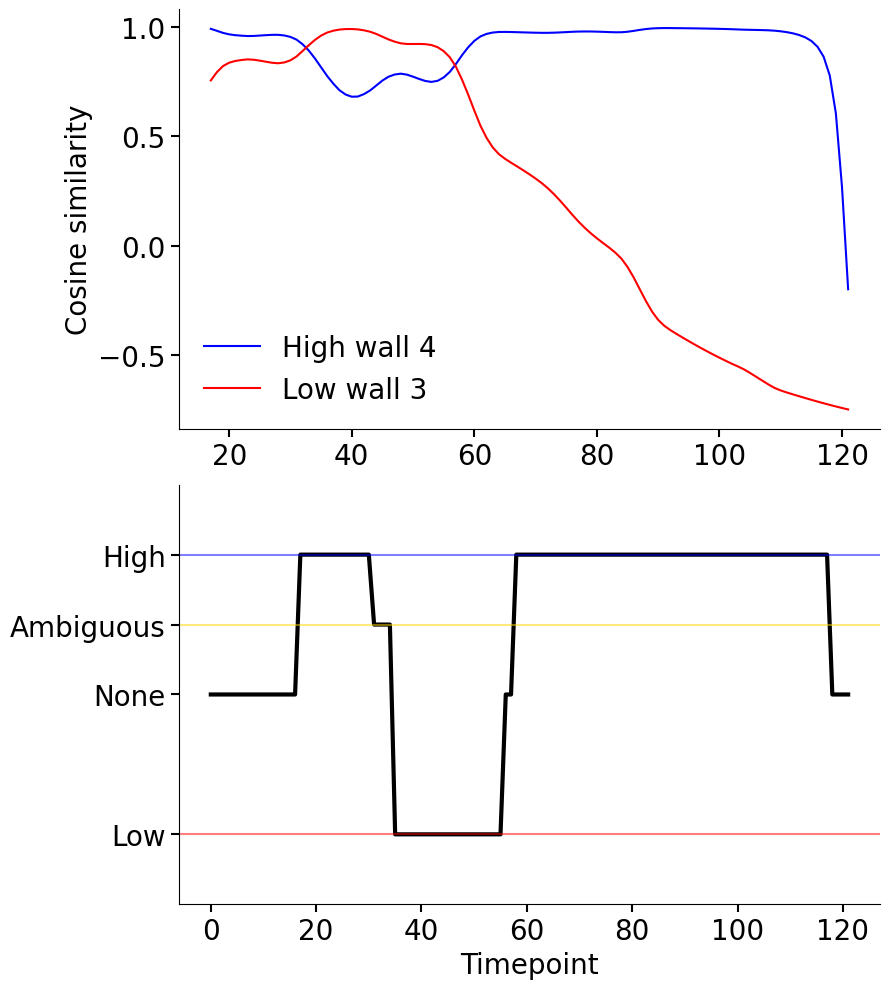

In [20]:
visualize_loser_change_of_mind(
    trial=trial,
    loser_id=loser_id,
    result=result,
    trial_walls=trial_walls
)

In [373]:
trial_walls

[4, 3]

In [371]:
loser_id, winner_id

(np.float64(1.0), np.float64(0.0))

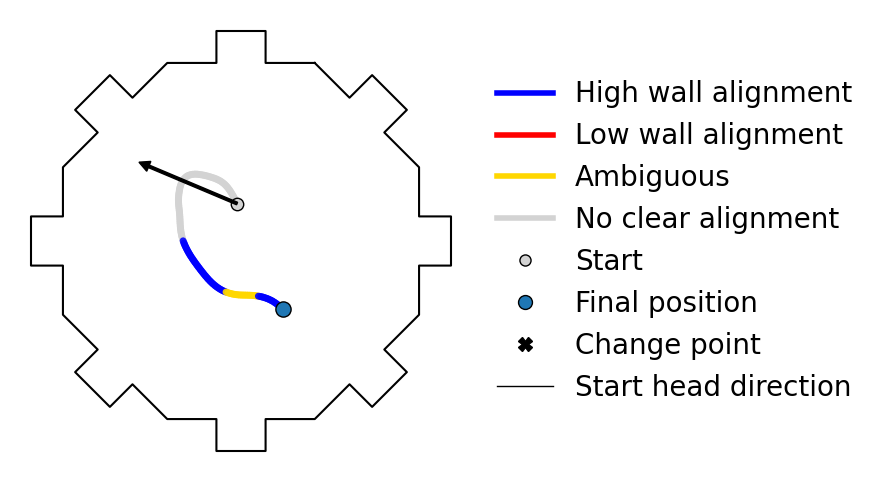

In [390]:
result = detect_loser_change_of_mind_trial(
    trial=trial,
    loser_id=loser_id,
    final_choice_wall_num=loser_choice,
    trial_walls=trial_walls
)

switch_result = count_alignment_switches(
    result["alignment_var"],
    min_block_len=5
)

trajectory = trajectory_vectors.extract_trial_player_trajectory(
    trial=trial,
    player_id=loser_id
)

headangles = trajectory_vectors.extract_trial_player_headangles(
    trial=trial,
    player_id=loser_id
)

headangle_vectors = trajectory_headangle.get_player_headangle_vectors_for_trial(headangles)

change_points = [
    switch["switch_frame"]
    for switch in switch_result["switches"]
]


plot_change_of_mind_example_in_octagon(
    trajectory=trajectory,
    alignment_var=result["alignment_var"],
    change_points=change_points,
    headangle_vectors=headangle_vectors,
    head_arrow_len=10
)
plt.show()

In [187]:
len(headangles), len(trajectory[0])

(121, 121)

In [189]:
from trajectory_analysis import trajectory_headangle

In [193]:
len(headangle_vectors[0])

121

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)


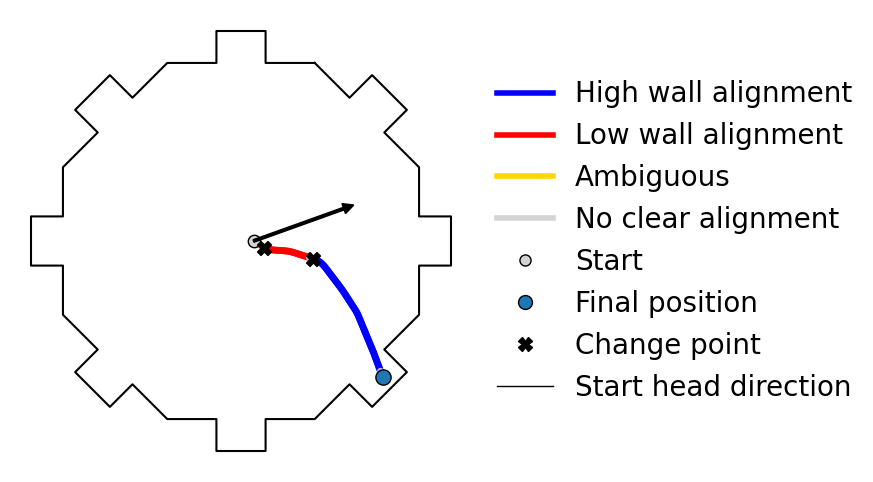

In [391]:
result = detect_loser_change_of_mind_trial(
    trial=trial,
    loser_id=winner_id,
    final_choice_wall_num=winner_choice,
    trial_walls=trial_walls
)

switch_result = count_alignment_switches(
    result["alignment_var"],
    min_block_len=5
)

trajectory = trajectory_vectors.extract_trial_player_trajectory(
    trial=trial,
    player_id=winner_id
)

headangles = trajectory_vectors.extract_trial_player_headangles(
    trial=trial,
    player_id=winner_id
)

headangle_vectors = trajectory_headangle.get_player_headangle_vectors_for_trial(headangles)

change_points = [
    switch["switch_frame"]
    for switch in switch_result["switches"]
]


plot_change_of_mind_example_in_octagon(
    trajectory=trajectory,
    alignment_var=result["alignment_var"],
    change_points=change_points,
    headangle_vectors=headangle_vectors,
    head_arrow_len=10
)
plt.show()

In [392]:
loser_id = loser_id
final_choice_wall_num = loser_choice
result = los_result

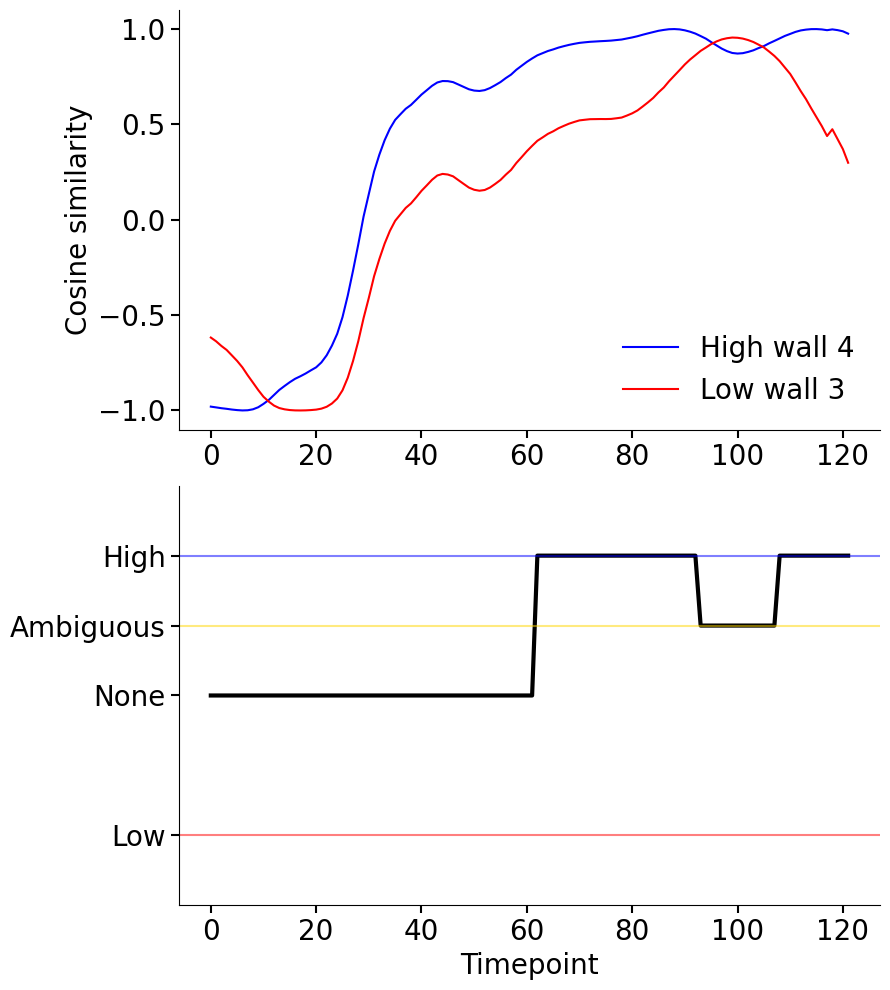

In [393]:
visualize_loser_change_of_mind(
    trial=trial,
    loser_id=loser_id,
    result=result,
    trial_walls=trial_walls
)

num. change of minds for solo v social, winner v loser, high choice v low choice

changes of mind per timepoint solo v social, winner v loser, high choice v low choice

In [21]:
import pandas as pd

In [412]:
trial_list = trial_lists_solo[5]
trial_index = 0
loser_ids = np.full(len(trial_list), 0)

In [407]:
test_solo_choice, test_solo_confident = loser_inferred_choice.infer_loser_choice_trial(
    trial_list,
    trial_index,
    loser_ids,
    trial_walls
)

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)


In [409]:
test_solo_choice,test_solo_confident

(np.int64(7), False)

In [22]:
com_rows = []

for list_index, trial_list in enumerate(trial_lists_social):

    winner_ids = get_indices.get_trigger_activators(trial_list)
    loser_ids = (winner_ids - 1) * -1

    for trial_index, trial in enumerate(trial_list):

        trial_walls = get_indices.get_walls(trial=trial)

        loser_choice, los_confident = loser_inferred_choice.infer_loser_choice_trial(
            trial_list,
            trial_index,
            loser_ids,
            trial_walls
        )

        winner_choice, win_confident = loser_inferred_choice.infer_loser_choice_trial(
            trial_list,
            trial_index,
            winner_ids,
            trial_walls
        )

        # Skip uncertain inferred choices
        if not los_confident or not win_confident:
            continue

        los_result = detect_loser_change_of_mind_trial(
            trial=trial,
            loser_id=loser_ids[trial_index],
            final_choice_wall_num=loser_choice,
            trial_walls=trial_walls
        )

        win_result = detect_loser_change_of_mind_trial(
            trial=trial,
            loser_id=winner_ids[trial_index],
            final_choice_wall_num=winner_choice,
            trial_walls=trial_walls
        )

        los_switch_result = count_alignment_switches(
            los_result["alignment_var"],
            min_block_len=5
        )

        win_switch_result = count_alignment_switches(
            win_result["alignment_var"],
            min_block_len=5
        )

        los_n_frames = len(los_result["alignment_var"])
        win_n_frames = len(win_result["alignment_var"])

        com_rows.append({
            "session_index": list_index,
            "trial_index": trial_index,
            "role": "Loser",
            "n_switches": los_switch_result["n_switches"],
            "n_frames": los_n_frames,
            "com_per_frame": los_switch_result["n_switches"] / los_n_frames if los_n_frames > 0 else np.nan
        })

        com_rows.append({
            "session_index": list_index,
            "trial_index": trial_index,
            "role": "Winner",
            "n_switches": win_switch_result["n_switches"],
            "n_frames": win_n_frames,
            "com_per_frame": win_switch_result["n_switches"] / win_n_frames if win_n_frames > 0 else np.nan
        })


com_df = pd.DataFrame(com_rows)

# Bin as 0, 1, 2+
com_df["com_bin"] = np.where(
    com_df["n_switches"] >= 2,
    "2+",
    com_df["n_switches"].astype(int).astype(str)
) 

# Proportion within role
plot_df = (
    com_df
    .groupby(["role", "com_bin"])
    .size()
    .reset_index(name="count")
)

plot_df["proportion"] = plot_df.groupby("role")["count"].transform(
    lambda x: x / x.sum()
)

# Ensure all bins exist for both roles
roles = ["Winner", "Loser"]
bins = ["0", "1", "2+"]

plot_df = (
    plot_df
    .set_index(["role", "com_bin"])
    .reindex(
        pd.MultiIndex.from_product([roles, bins], names=["role", "com_bin"]),
        fill_value=0
    )
    .reset_index()
)

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

In [23]:
com_df

,session_index,trial_index,role,n_switches,n_frames,com_per_frame,com_bin
0,0,2,Loser,1,166,0.006024096,1
1,0,2,Winner,0,166,0.000000000,0
2,0,3,Loser,0,78,0.000000000,0
3,0,3,Winner,0,78,0.000000000,0
4,0,6,Loser,0,177,0.000000000,0
...,...,...,...,...,...,...,...
16365,100,125,Winner,1,103,0.009708738,1
16366,100,127,Loser,1,127,0.007874016,1
16367,100,127,Winner,0,127,0.000000000,0
16368,100,128,Loser,0,90,0.000000000,0


In [24]:
for i in range(len(com_rows)):
    if com_rows[i]['n_switches'] >= 2:
        print(com_rows[i]['n_switches'])
        print(f"i: {i}")

4
i: 28
2
i: 31
3
i: 39
2
i: 43
2
i: 44
2
i: 48
5
i: 54
3
i: 55
2
i: 62
2
i: 67
3
i: 72
3
i: 73
2
i: 78
2
i: 80
2
i: 94
2
i: 99
2
i: 102
2
i: 111
2
i: 114
2
i: 127
2
i: 129
2
i: 147
2
i: 202
2
i: 205
3
i: 235
2
i: 249
2
i: 250
2
i: 316
2
i: 365
3
i: 384
2
i: 390
3
i: 411
2
i: 421
2
i: 490
2
i: 559
3
i: 578
3
i: 579
3
i: 617
2
i: 628
2
i: 632
2
i: 635
5
i: 647
2
i: 658
2
i: 662
2
i: 664
4
i: 665
2
i: 668
2
i: 669
3
i: 674
2
i: 675
3
i: 677
2
i: 681
2
i: 683
4
i: 689
2
i: 690
3
i: 695
2
i: 697
3
i: 698
2
i: 699
2
i: 702
3
i: 714
2
i: 715
3
i: 734
2
i: 749
2
i: 789
2
i: 793
2
i: 801
2
i: 811
2
i: 843
2
i: 854
2
i: 912
2
i: 913
2
i: 962
2
i: 1032
2
i: 1063
2
i: 1064
2
i: 1075
2
i: 1104
3
i: 1106
2
i: 1111
2
i: 1131
2
i: 1135
2
i: 1152
2
i: 1169
2
i: 1190
2
i: 1217
2
i: 1219
3
i: 1220
2
i: 1224
2
i: 1226
2
i: 1232
3
i: 1263
6
i: 1270
2
i: 1314
2
i: 1335
5
i: 1339
2
i: 1347
3
i: 1364
3
i: 1366
2
i: 1367
2
i: 1372
3
i: 1375
3
i: 1385
2
i: 1391
2
i: 1392
2
i: 1397
2
i: 1399
3
i: 1424
2
i: 1433

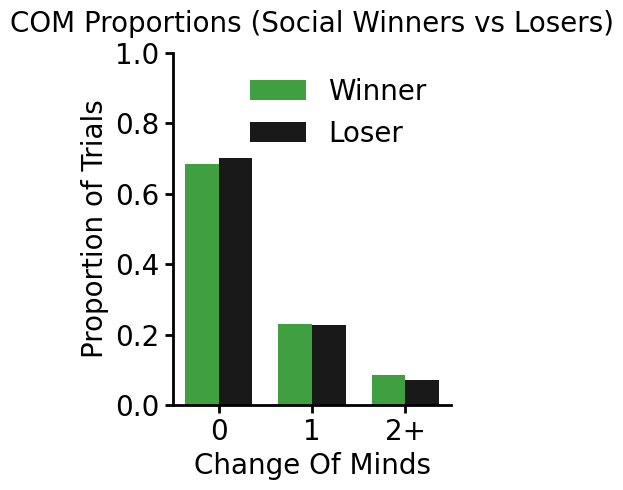

In [480]:
fig, ax = plt.subplots(figsize=(4, 5))

x = np.arange(len(bins))
bar_width = 0.36

winner_vals = plot_df[plot_df["role"] == "Winner"]["proportion"].values
loser_vals = plot_df[plot_df["role"] == "Loser"]["proportion"].values

ax.bar(
    x - bar_width / 2,
    winner_vals,
    width=bar_width,
    color="green",
    alpha=0.75,
    label="Winner"
)

ax.bar(
    x + bar_width / 2,
    loser_vals,
    width=bar_width,
    color="black",
    alpha=0.9,
    label="Loser"
)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=20)

ax.set_xlabel("Change Of Minds", fontsize=20)
ax.set_ylabel("Proportion of Trials", fontsize=20)
ax.set_title("COM Proportions (Social Winners vs Losers)", fontsize=20, pad=15)

ax.tick_params(axis="both", labelsize=20, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(
    frameon=False,
    fontsize=20,
    title_fontsize=20
)

plt.tight_layout()
plt.show()

In [494]:
summary_df = (
    com_df
    .groupby("role")["com_per_frame"]
    .agg(["mean", "sem"])
    .reset_index()
)

In [495]:
summary_df

,role,mean,sem
0,Loser,0.003270656,0.000065557
1,Winner,0.003539317,0.000067671


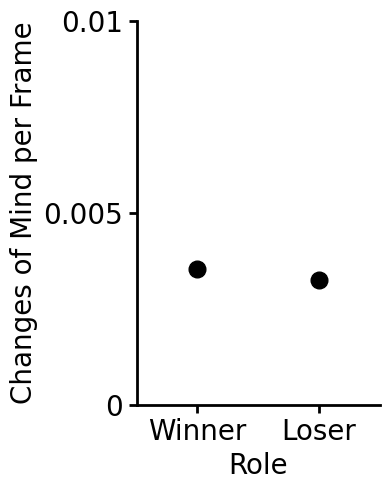

In [498]:
fig, ax = plt.subplots(figsize=(4, 5))

roles = ["Winner", "Loser"]
x = np.arange(len(roles))

means = [
    summary_df.loc[summary_df["role"] == role, "mean"].iloc[0]
    for role in roles
]

sems = [
    summary_df.loc[summary_df["role"] == role, "sem"].iloc[0]
    for role in roles
]

ax.errorbar(
    x,
    means,
    yerr=sems,
    fmt="o",
    color="black",
    markersize=12,
    linewidth=2.5,
    capsize=0
)

ax.set_xticks(x)
ax.set_xticklabels(roles, fontsize=20)
ax.set_xlim(-0.5, len(roles) - 0.5)

ax.set_yticks([0, 0.005, 0.01])
ax.set_yticklabels([0, 0.005, 0.01],fontsize=20)


ax.set_ylabel("Changes of Mind per Frame", fontsize=20)
ax.set_xlabel("Role", fontsize=20)

ax.tick_params(axis="both", labelsize=20, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

Solo v social

In [450]:
trial_list=trial_lists_solo[10]

In [25]:
def get_chosen_walls(trial_list):

    chosen_walls = np.zeros(len(trial_list))
    for i in range(len(trial_list)): 
        this_trial = trial_list[i]
        

        # only select from the trigger event chosen by the server
        selected_trigger_activation_event = this_trial[this_trial['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION]
        wall_chosen = selected_trigger_activation_event[globals.WALL_TRIGGERED].unique()
        wall_chosen_filter_nans = wall_chosen[~np.isnan(wall_chosen)]
        wall_chosen_val = wall_chosen_filter_nans.item()

        chosen_walls[i] = int(wall_chosen_val)

    return chosen_walls


In [454]:
choices = get_chosen_walls(trial_list)

In [455]:
choices

array([2., 5., 3., 1., 4., 5., 2., 5., 4., 7., 1., 6., 5., 4., 8., 5., 2.,
       4., 8., 1., 4., 5., 6., 3., 8., 5., 5., 2., 4., 8., 7., 5., 7., 4.])

In [28]:
com_solo_rows = []

for list_index, trial_list in enumerate(second_solo_lists):

    if list_index == 145:
        continue

    print(f"Processing solo list {list_index} with {len(trial_list)} trials...")

    choices = get_indices.get_chosen_walls(trial_list)

    for trial_index, trial in enumerate(trial_list):

        trial_walls = get_indices.get_walls(trial=trial)

        result = detect_loser_change_of_mind_trial(
            trial=trial,
            loser_id=0,
            final_choice_wall_num=choices[trial_index],
            trial_walls=trial_walls
        )

        switch_result = count_alignment_switches(
            result["alignment_var"],
            min_block_len=5
        )

        n_frames = len(result["alignment_var"])

        com_solo_rows.append({
            "session_index": list_index,
            "trial_index": trial_index,
            "role": "Solo",
            "n_switches": switch_result["n_switches"],
            "n_frames": n_frames,
            "com_per_frame": switch_result["n_switches"] / n_frames if n_frames > 0 else np.nan
        })


com_solo_df = pd.DataFrame(com_solo_rows)

# Bin as 0, 1, 2+
com_solo_df["com_bin"] = np.where(
    com_solo_df["n_switches"] >= 2,
    "2+",
    com_solo_df["n_switches"].astype(int).astype(str)
) 

# Proportion within role
plot_solo_df = (
    com_solo_df
    .groupby(["role", "com_bin"])
    .size()
    .reset_index(name="count")
)

plot_solo_df["proportion"] = plot_solo_df.groupby("role")["count"].transform(
    lambda x: x / x.sum()
)

# Ensure all bins exist for both roles
roles = ["Solo"]
bins = ["0", "1", "2+"]

plot_solo_df = (
    plot_solo_df
    .set_index(["role", "com_bin"])
    .reindex(
        pd.MultiIndex.from_product([roles, bins], names=["role", "com_bin"]),
        fill_value=0
    )
    .reset_index()
)

Processing solo list 0 with 36 trials...
Processing solo list 1 with 36 trials...


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)


Processing solo list 2 with 33 trials...
Processing solo list 3 with 33 trials...


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

Processing solo list 4 with 35 trials...


...

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

Processing solo list 200 with 60 trials...


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

Processing solo list 201 with 59 trials...


/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

In [29]:
com_social_df = com_df.copy()
com_social_df["condition"] = "Social"

com_solo_df["condition"] = "Solo"

com_condition_df = pd.concat(
    [
        com_solo_df[["session_index", "trial_index", "n_switches", "com_per_frame", "com_bin", "condition"]],
        com_social_df[["session_index", "trial_index", "n_switches", "com_per_frame", "com_bin", "condition"]]
    ],
    ignore_index=True
)


In [31]:
# Proportion within role
plot_df_solo_social = (
    com_condition_df
    .groupby(["condition", "com_bin"])
    .size()
    .reset_index(name="count")
)

plot_df_solo_social["proportion"] = plot_df_solo_social.groupby("condition")["count"].transform(
    lambda x: x / x.sum()
)

# Ensure all bins exist for both roles
conditions = ["Solo", "Social"]
bins = ["0", "1", "2+"]

plot_df_solo_social = (
    plot_df_solo_social
    .set_index(["condition", "com_bin"])
    .reindex(
        pd.MultiIndex.from_product([conditions, bins], names=["condition", "com_bin"]),
        fill_value=0
    )
    .reset_index()
)

In [32]:
plot_df_solo_social

,condition,com_bin,count,proportion
0,Solo,0,7828,0.689995593
1,Solo,1,2611,0.230145439
2,Solo,2+,906,0.079858969
3,Social,0,11355,0.693646915
4,Social,1,3733,0.228039096
5,Social,2+,1282,0.078313989


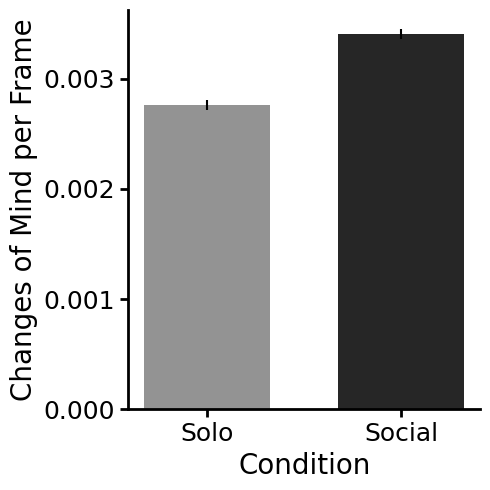

In [33]:
summary_df = (
    com_condition_df
    .groupby("condition")["com_per_frame"]
    .agg(["mean", "sem"])
    .reset_index()
)

conditions = ["Solo", "Social"]

means = [
    summary_df.loc[summary_df["condition"] == c, "mean"].iloc[0]
    for c in conditions
]

sems = [
    summary_df.loc[summary_df["condition"] == c, "sem"].iloc[0]
    for c in conditions
]

fig, ax = plt.subplots(figsize=(5, 5))

x = np.arange(len(conditions))

ax.bar(
    x,
    means,
    yerr=sems,
    capsize=0,
    color=["grey", "black"],
    alpha=0.85,
    width=0.65
)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=20)

ax.set_ylabel("Changes of Mind per Frame", fontsize=20)
ax.set_xlabel("Condition", fontsize=20)

ax.tick_params(axis="both", labelsize=18, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

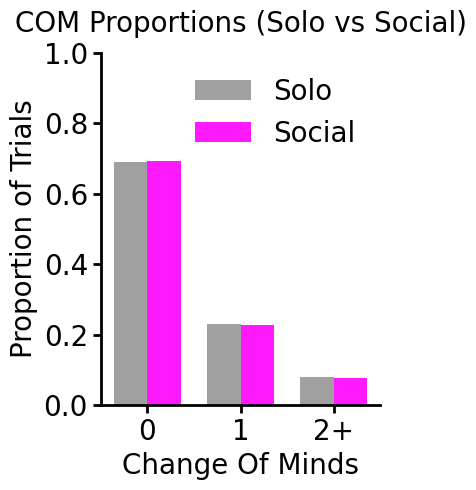

In [35]:
fig, ax = plt.subplots(figsize=(4, 5))

x = np.arange(len(bins))
bar_width = 0.36

solo_vals = plot_df_solo_social[plot_df_solo_social["condition"] == "Solo"]["proportion"].values
social_vals = plot_df_solo_social[plot_df_solo_social["condition"] == "Social"]["proportion"].values

ax.bar(
    x - bar_width / 2,
    solo_vals,
    width=bar_width,
    color="grey",
    alpha=0.75,
    label="Solo"
)

ax.bar(
    x + bar_width / 2,
    social_vals,
    width=bar_width,
    color="magenta",
    alpha=0.9,
    label="Social"
)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=20)

ax.set_xlabel("Change Of Minds", fontsize=20)
ax.set_ylabel("Proportion of Trials", fontsize=20)
ax.set_title("COM Proportions (Solo vs Social)", fontsize=20, pad=15)

ax.tick_params(axis="both", labelsize=20, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(
    frameon=False,
    fontsize=20,
    title_fontsize=20
)

plt.tight_layout()
plt.show()

In [36]:
summary_df = (
    com_condition_df
    .groupby("condition")["com_per_frame"]
    .agg(["mean", "sem"])
    .reset_index()
)

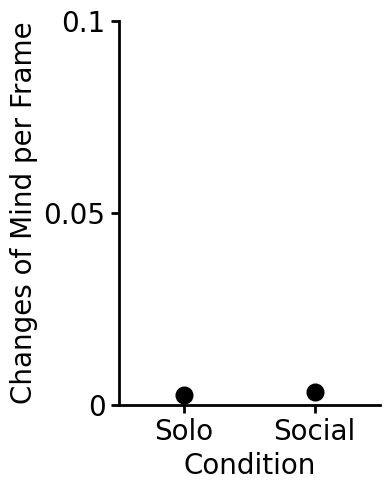

In [37]:
fig, ax = plt.subplots(figsize=(4, 5))

conditions = ["Solo", "Social"]
x = np.arange(len(conditions))

means = [
    summary_df.loc[summary_df["condition"] == condition, "mean"].iloc[0]
    for condition in conditions
]

sems = [
    summary_df.loc[summary_df["condition"] == condition, "sem"].iloc[0]
    for condition in conditions
]

ax.errorbar(
    x,
    means,
    yerr=sems,
    fmt="o",
    color="black",
    markersize=12,
    linewidth=2.5,
    capsize=0
)

ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=20)
ax.set_xlim(-0.5, len(conditions) - 0.5)

ax.set_yticks([0, 0.05, 0.1])
ax.set_yticklabels([0, 0.05, 0.1],fontsize=20)


ax.set_ylabel("Changes of Mind per Frame", fontsize=20)
ax.set_xlabel("Condition", fontsize=20)

ax.tick_params(axis="both", labelsize=20, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

In [40]:
# Add high/low choice label to solo rows
com_solo_rows = []

for list_index, trial_list in enumerate(second_solo_lists):

    if list_index == 145:
        continue

    choices = get_indices.get_chosen_walls(trial_list)

    for trial_index, trial in enumerate(trial_list):

        trial_walls = get_indices.get_walls(trial=trial)
        high_wall = int(trial_walls[0])
        low_wall = int(trial_walls[1])
        chosen_wall = int(choices[trial_index])

        if chosen_wall == high_wall:
            choice_type = "High Choice"
        elif chosen_wall == low_wall:
            choice_type = "Low Choice"
        else:
            continue

        result = detect_loser_change_of_mind_trial(
            trial=trial,
            loser_id=0,
            final_choice_wall_num=chosen_wall,
            trial_walls=trial_walls
        )

        switch_result = count_alignment_switches(
            result["alignment_var"],
            min_block_len=5
        )

        n_frames = len(result["alignment_var"])

        com_solo_rows.append({
            "session_index": list_index,
            "trial_index": trial_index,
            "choice_type": choice_type,
            "chosen_wall": chosen_wall,
            "n_switches": switch_result["n_switches"],
            "n_frames": n_frames,
            "com_per_frame": switch_result["n_switches"] / n_frames if n_frames > 0 else np.nan
        })

com_solo_df = pd.DataFrame(com_solo_rows)

com_solo_df["com_bin"] = np.where(
    com_solo_df["n_switches"] >= 2,
    "2+",
    com_solo_df["n_switches"].astype(int).astype(str)
)

/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_norms[wall_num] * player_vector_norm)
/Users/benny/Repos/octagon_analysis/trajectory_analysis/trajectory_vectors.py:321: RuntimeWarning: invalid value encountered in scalar divide
  cosine_similarity_this_wall = dot_product[wall_num]/(player_to_alcove_vector_no

In [41]:
bins = ["0", "1", "2+"]
choice_types = ["High Choice", "Low Choice"]

plot_df = (
    com_solo_df
    .groupby(["choice_type", "com_bin"])
    .size()
    .reset_index(name="count")
)

plot_df["proportion"] = plot_df.groupby("choice_type")["count"].transform(
    lambda x: x / x.sum()
)

plot_df = (
    plot_df
    .set_index(["choice_type", "com_bin"])
    .reindex(
        pd.MultiIndex.from_product(
            [choice_types, bins],
            names=["choice_type", "com_bin"]
        ),
        fill_value=0
    )
    .reset_index()
)

In [42]:
plot_df

,choice_type,com_bin,count,proportion
0,High Choice,0,6402,0.679906542
1,High Choice,1,2262,0.240229397
2,High Choice,2+,752,0.079864061
3,Low Choice,0,1426,0.739243131
4,Low Choice,1,349,0.180922758
5,Low Choice,2+,154,0.079834111


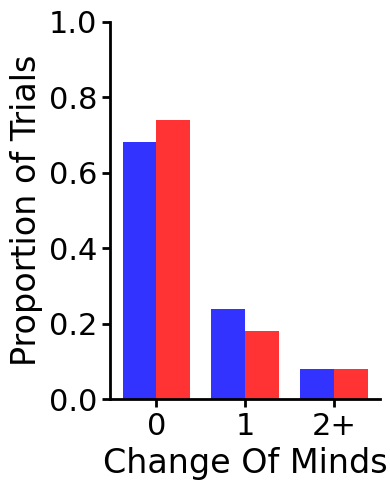

In [43]:
fig, ax = plt.subplots(figsize=(4, 5))

x = np.arange(len(bins))
bar_width = 0.38

high_vals = plot_df[plot_df["choice_type"] == "High Choice"]["proportion"].values
low_vals = plot_df[plot_df["choice_type"] == "Low Choice"]["proportion"].values

ax.bar(
    x - bar_width / 2,
    high_vals,
    width=bar_width,
    color="blue",
    alpha=0.8,
    label="High Choice"
)

ax.bar(
    x + bar_width / 2,
    low_vals,
    width=bar_width,
    color="red",
    alpha=0.8,
    label="Low Choice"
)

ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=22)

ax.set_ylim(0, 1)

ax.set_xlabel("Change Of Minds", fontsize=24)
ax.set_ylabel("Proportion of Trials", fontsize=24)

ax.tick_params(axis="both", labelsize=22, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

#ax.legend(frameon=False, fontsize=20)

plt.tight_layout()
plt.show()

In [44]:
summary_df = (
    com_solo_df
    .groupby("choice_type")["com_per_frame"]
    .agg(["mean", "sem"])
    .reset_index()
)

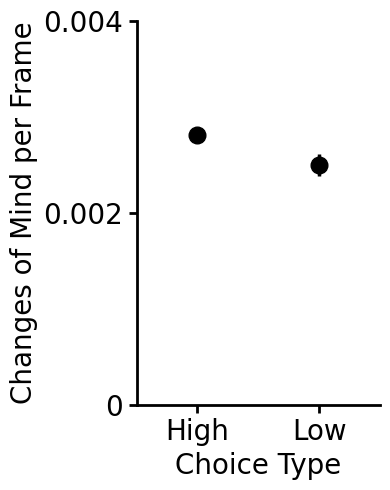

In [45]:
fig, ax = plt.subplots(figsize=(4, 5))

choice_types = ["High Choice", "Low Choice"]
x = np.arange(len(choice_types))

means = [
    summary_df.loc[summary_df["choice_type"] == choice_type, "mean"].iloc[0]
    for choice_type in choice_types
]

sems = [
    summary_df.loc[summary_df["choice_type"] == choice_type, "sem"].iloc[0]
    for choice_type in choice_types
]

ax.errorbar(
    x,
    means,
    yerr=sems,
    fmt="o",
    color="black",
    markersize=12,
    linewidth=2.5,
    capsize=0
)

ax.set_xticks(x)
ax.set_xticklabels(["High", "Low"], fontsize=20)
ax.set_xlim(-0.5, len(choice_types) - 0.5)

ax.set_yticks([0, 0.002, 0.004])
ax.set_yticklabels([0, 0.002, 0.004],fontsize=20)

ax.set_ylabel("Changes of Mind per Frame", fontsize=20)
ax.set_xlabel("Choice Type", fontsize=20)

ax.tick_params(axis="both", labelsize=20, width=2, length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()